In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier

In [3]:
loan200 = pd.read_csv("data/loan200.csv")
loan200

,outcome,payment_inc_ratio,dti
0,target,9.00000,22.50
1,default,5.46933,21.33
2,paid off,6.90294,8.97
3,paid off,11.14800,1.83
4,default,3.72120,10.81
...,...,...,...
196,default,11.66300,26.09
197,default,2.97641,16.41
198,default,1.96846,19.98
199,paid off,9.64200,20.17


In [4]:
predictors = ["payment_inc_ratio", "dti"]
outcome = "outcome"

newloan = loan200.loc[0:0, predictors]
newloan

,payment_inc_ratio,dti
0,9.0,22.5


In [5]:
X = loan200.loc[1:, predictors]
y = loan200.loc[1:, outcome]

knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X, y)
print(knn.predict(newloan))
knn.predict_proba(newloan)

['paid off']


array([[0.45, 0.55]])

In [6]:
y

1       default
2      paid off
3      paid off
4       default
5      paid off
         ...   
196     default
197     default
198     default
199    paid off
200    paid off
Name: outcome, Length: 200, dtype: object

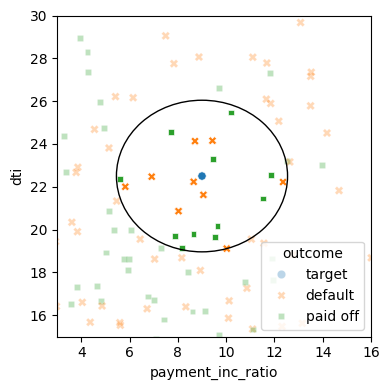

In [7]:
nbrs = knn.kneighbors(newloan)
maxDistance = np.max(nbrs[0][0])

fig, ax = plt.subplots(figsize=(4, 4))

sns.scatterplot(x='payment_inc_ratio', y='dti', style='outcome', 
                hue='outcome', data=loan200, alpha=0.3, ax=ax)

sns.scatterplot(x='payment_inc_ratio', y='dti', style='outcome', 
                hue='outcome', 
                data=pd.concat([loan200.loc[0:0, :], loan200.loc[nbrs[1][0] + 1,:]]), 
                ax=ax, legend=False)

ellipse = Ellipse(xy=newloan.values[0], 
                  width=2 * maxDistance, height=2 * maxDistance,
                  edgecolor='black', fc='None', lw=1)


ax.add_patch(ellipse)
ax.set_xlim(3, 16)
ax.set_ylim(15, 30)

plt.tight_layout()
plt.show()



In [8]:
loan_data = pd.read_csv("data/loan_data.csv")
loan_data = loan_data.drop(columns=['Unnamed: 0', 'status'])
loan_data['outcome'] = pd.Categorical(loan_data['outcome'], 
                                      categories=['paid off', 'default'], 
                                      ordered=True)


predictors = ['payment_inc_ratio', 'dti', 'revol_bal', 'revol_util']
outcome = 'outcome'

newloan = loan_data.loc[0:0, predictors]
print(newloan)
X = loan_data.loc[1:, predictors]
y = loan_data.loc[1:, outcome]

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, y)

nbrs = knn.kneighbors(newloan)
print(X.iloc[nbrs[1][0], :])

   payment_inc_ratio  dti  revol_bal  revol_util
0             2.3932  1.0       1687         9.4
       payment_inc_ratio   dti  revol_bal  revol_util
35536            1.47212  1.46       1686        10.0
33651            3.38178  6.37       1688         8.4
25863            2.36303  1.39       1691         3.5
42953            1.28160  7.14       1684         3.9
43599            4.12244  8.98       1684         7.2


In [9]:
from sklearn.preprocessing import StandardScaler

newloan = loan_data.loc[0:0, predictors]
X = loan_data.loc[1:, predictors]
y = loan_data.loc[1:, outcome]

scaler = StandardScaler()
scaler.fit(X * 1.0)

X_std = scaler.transform(X * 1.0)
newloan_std = scaler.transform(newloan * 1.0)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_std, y)

nbrs = knn.kneighbors(newloan_std)
print(X.iloc[nbrs[1][0], :])


       payment_inc_ratio   dti  revol_bal  revol_util
2080             2.61091  1.03       1218         9.7
1438             2.34343  0.51        278         9.9
30215            2.71200  1.34       1075         8.5
28542            2.39760  0.74       2917         7.4
44737            2.34309  1.37        488         7.2


In [10]:
nbrs

(array([[0.05750762, 0.09802148, 0.09887142, 0.10540438, 0.11645144]]),
 array([[ 2079,  1437, 30214, 28541, 44736]]))

In [11]:
X_std

array([[-0.81160622, -1.3936398 , -0.48040655, -0.92227466],
       [ 0.39485675,  0.25622784, -0.27779177, -0.76890846],
       [ 0.9809797 , -0.79715932, -0.21938255,  1.40181312],
       ...,
       [ 0.45784996, -1.07762365, -0.41248653,  0.66644186],
       [-0.37051305,  1.41890392, -0.22680197, -0.9301396 ],
       [ 0.90037372, -1.09474119,  0.09053988,  1.39788066]],
      shape=(45341, 4))

In [12]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from dmba import plotDecisionTree, textDecisionTree

loan3000 = pd.read_csv("data/loan3000.csv")

predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

X = loan3000[predictors]
y = loan3000[outcome]

loan_tree = DecisionTreeClassifier(random_state=1, criterion='entropy',
                                   min_impurity_decrease=0.003)
loan_tree.fit(X, y)



no display found. Using non-interactive Agg backend


,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.003
,class_weight,None


In [13]:

plt.figure(figsize=(10,6))
plot_tree(loan_tree, feature_names=predictors, class_names=loan_tree.classes_, filled=True)
plt.show()

%matplotlib inline

/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_971/1632524251.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [14]:
print(textDecisionTree(loan_tree))

node=0 test node: go to node 1 if 0 <= 0.5750000178813934 else to node 6
  node=1 test node: go to node 2 if 0 <= 0.32500000298023224 else to node 3
    node=2 leaf node: [[np.float64(0.785), np.float64(0.215)]]
    node=3 test node: go to node 4 if 1 <= 10.42264986038208 else to node 5
      node=4 leaf node: [[np.float64(0.488), np.float64(0.512)]]
      node=5 leaf node: [[np.float64(0.613), np.float64(0.387)]]
  node=6 test node: go to node 7 if 1 <= 9.19082498550415 else to node 10
    node=7 test node: go to node 8 if 0 <= 0.7249999940395355 else to node 9
      node=8 leaf node: [[np.float64(0.247), np.float64(0.753)]]
      node=9 leaf node: [[np.float64(0.073), np.float64(0.927)]]
    node=10 leaf node: [[np.float64(0.457), np.float64(0.543)]]


In [15]:
from sklearn.ensemble import RandomForestClassifier

predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

X = loan3000[predictors]
y = loan3000[outcome]

model_rf = RandomForestClassifier(n_estimators=500, oob_score=True, random_state=1)
model_rf.fit(X, y)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [16]:
n_estimator = list(range(20, 510, 5))
oobScores = []
for n in n_estimator:
    rf = RandomForestClassifier(n_estimators=n, 
                                criterion='entropy', max_depth=5,
                                random_state=1, oob_score=True)
    rf.fit(X, y)
    oobScores.append(rf.oob_score_)

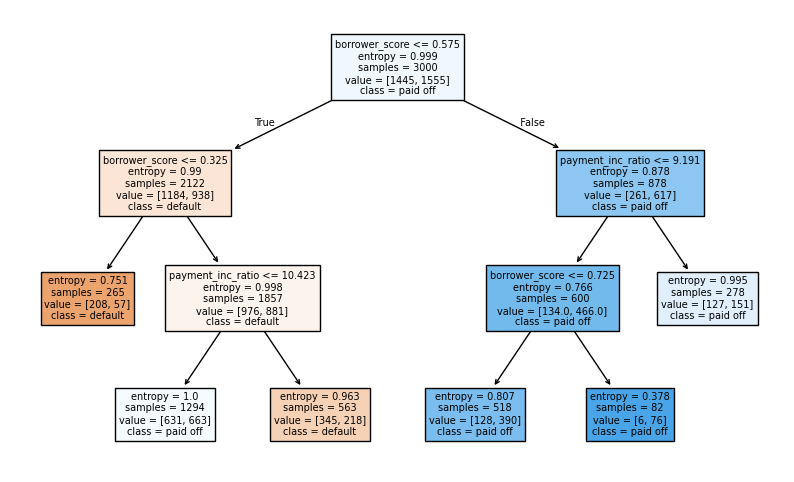

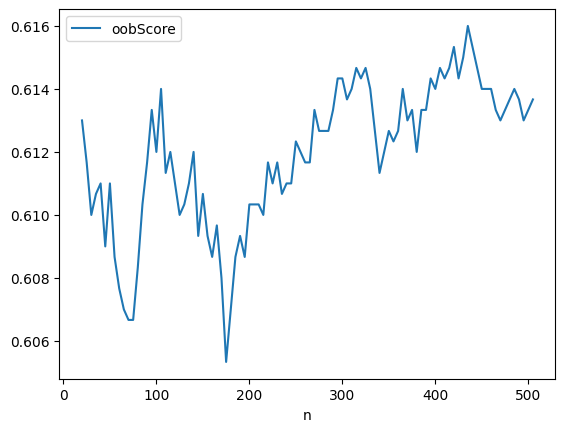

In [17]:


pd.DataFrame({
    'n': n_estimator, 
    'oobScore': oobScores
}).plot(x='n', y='oobScore')
plt.show()



In [18]:
predictions = X.copy()
predictions['prediction'] = rf.predict(X)
predictions.head()


,borrower_score,payment_inc_ratio,prediction
0,0.40,5.11135,default
1,0.40,5.43165,default
2,0.70,9.23003,paid off
3,0.40,2.33482,paid off
4,0.45,12.10320,default


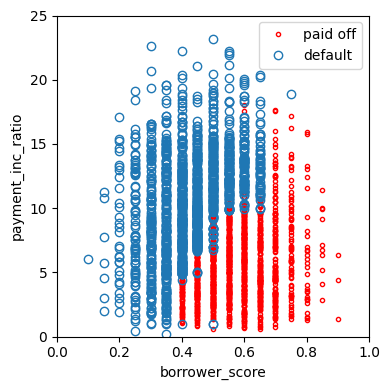

In [19]:

fig, ax = plt.subplots(figsize=(4, 4))

predictions.loc[predictions.prediction=='paid off'].plot(
    x='borrower_score', y='payment_inc_ratio', style='.',
    markerfacecolor='none', markeredgecolor="red", ax=ax)


predictions.loc[predictions.prediction=='default'].plot(
    x='borrower_score', y='payment_inc_ratio', style='o',
    markerfacecolor='none', markeredgecolor='C0', ax=ax)


ax.legend(['paid off', 'default']);
ax.set_xlim(0, 1)
ax.set_ylim(0, 25)
ax.set_xlabel('borrower_score')
ax.set_ylabel('payment_inc_ratio')

plt.tight_layout()
plt.show()


In [ ]:
# predictors = ['loan_amnt', 'term', 'annual_inc', 'dti', 
#               'payment_inc_ratio', 'revol_bal', 'revol_util', 
#               'purpose', 'delinq_2yrs_zero', 'pub_rec_zero', 
#               'open_acc', 'grade', 'emp_length', 'purpose_', 
#               'home_', 'emp_len_', 'borrower_score']
# outcome = 'outcome'

# X = pd.get_dummies(loan_data[predictors], drop_first=True, dtype=int)
# y = loan_data[outcome]

# rf_all = RandomForestClassifier(n_estimators=500, random_state=1)
# rf_all.fit(X, y)

# rf_all_entropy = RandomForestClassifier(n_estimators=500, random_state=1,
#                                         criterion='entropy')
# print(rf_all_entropy.fit(X, y))

RandomForestClassifier(criterion='entropy', n_estimators=500, random_state=1)


In [21]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from collections import defaultdict


# rf = RandomForestClassifier(n_estimators=500)
# scores = defaultdict(list)
 
# # crossvalidate the scores on a number of different random splits of the data
# for _ in range(3):
#     train_X, valid_X, train_y, valid_y = train_test_split(X, y, 
#                                                           test_size=0.3)
#     rf.fit(train_X, train_y)
#     acc = metrics.accuracy_score(valid_y, rf.predict(valid_X))
#     for column in X.columns:
#         X_t = valid_X.copy()
#         X_t[column] = np.random.permutation(X_t[column].values)
#         shuff_acc = metrics.accuracy_score(valid_y, rf.predict(X_t))
#         scores[column].append((acc-shuff_acc)/acc)
# print('Features sorted by their score:')
# print(sorted([(round(np.mean(score), 4), feat) for
#               feat, score in scores.items()], reverse=True))



In [22]:
# importances = rf_all.feature_importances_

# df = pd.DataFrame({
#     'feature': X.columns, 
#     'Accuracy decrease': [np.mean(scores[column]) for column in 
#                          X.columns],
#     'Gini decrease': rf_all.feature_importances_, 
#     'Entropy decrease': rf_all_entropy.feature_importances_,
# })
# df = df.sort_values('Accuracy decrease')

# fig, axes = plt.subplots(ncols=2, figsize=(8, 5))
# ax = df.plot(kind='barh', x='feature', y='Accuracy decrease', 
#              legend=False, ax=axes[0])
# ax.set_ylabel('')

# ax = df.plot(kind='barh', x='feature', y='Gini decrease', 
#              legend=False, ax=axes[1])
# ax.set_ylabel('')
# ax.get_yaxis().set_visible(False)

# plt.tight_layout()
# plt.show()

In [23]:
from xgboost import XGBClassifier
predictors = ['loan_amnt', 'term', 'annual_inc', 'dti', 
              'payment_inc_ratio', 'revol_bal', 'revol_util', 
              'purpose', 'delinq_2yrs_zero', 'pub_rec_zero', 
              'open_acc', 'grade', 'emp_length', 'purpose_', 
              'home_', 'emp_len_', 'borrower_score']
outcome = 'outcome'

X = pd.get_dummies(loan_data[predictors], drop_first=True, dtype=int)
y = pd.Series([1 if o == 'default' else 0 for o in loan_data[outcome]])

train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=10000)

xgb_default = XGBClassifier(objective='binary:logistic', n_estimators=250, max_depth=6,
                            reg_lambda=0, learning_rate=0.3, subsample=1,
                            eval_metric='error')
xgb_default.fit(train_X, train_y)

xgb_penalty = XGBClassifier(objective='binary:logistic', n_estimators=250, max_depth=6,
                            reg_lambda=1000, learning_rate=0.1, subsample=0.63,
                            eval_metric='error')
print(xgb_penalty.fit(train_X, train_y))

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='error', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=250,
              n_jobs=None, num_parallel_tree=None, ...)


In [24]:


pred_default = xgb_default.predict_proba(train_X)[:, 1]
error_default = abs(train_y - pred_default) > 0.5
print('default (train): ', np.mean(error_default))

pred_default = xgb_default.predict_proba(valid_X)[:, 1]
error_default = abs(valid_y - pred_default) > 0.5
print('default: ', np.mean(error_default))

pred_penalty = xgb_penalty.predict_proba(valid_X)[:, 1]
error_penalty = abs(valid_y - pred_penalty) > 0.5
print('penalty: ', np.mean(error_penalty))



default (train):  0.10653047365740478
default:  0.3526
penalty:  0.3259


In [25]:


results = []
for ntree_limit in range(1, 250):
    iteration_range = [1, ntree_limit + 1]
    train_default = xgb_default.predict_proba(train_X, iteration_range=iteration_range)[:, 1]
    train_penalty = xgb_penalty.predict_proba(train_X, iteration_range=iteration_range)[:, 1]
    pred_default = xgb_default.predict_proba(valid_X, iteration_range=iteration_range)[:, 1]
    pred_penalty = xgb_penalty.predict_proba(valid_X, iteration_range=iteration_range)[:, 1]
    results.append({
        'iterations': ntree_limit,
        'default train': np.mean(abs(train_y - train_default) > 0.5),
        'penalty train': np.mean(abs(train_y - train_penalty) > 0.5),
        'default test': np.mean(abs(valid_y - pred_default) > 0.5),
        'penalty test': np.mean(abs(valid_y - pred_penalty) > 0.5),
    })

results = pd.DataFrame(results)
print(results.head())



   iterations  default train  penalty train  default test  penalty test
0           1       0.343727       0.366448        0.3569        0.3698
1           2       0.332664       0.348424        0.3473        0.3587
2           3       0.326184       0.341294        0.3428        0.3468
3           4       0.321657       0.339398        0.3362        0.3450
4           5       0.319761       0.338040        0.3355        0.3441


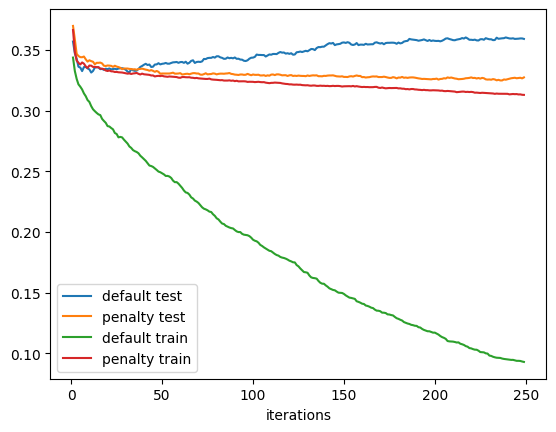

In [26]:


ax = results.plot(x='iterations', y='default test')
results.plot(x='iterations', y='penalty test', ax=ax)
results.plot(x='iterations', y='default train', ax=ax)
results.plot(x='iterations', y='penalty train', ax=ax)
plt.show()



In [27]:
from itertools import product

idx = np.random.choice(range(5), size=len(X), replace=True)
error = []
for eta, max_depth in product([0.1, 0.5, 0.9], [3, 6, 9]):
    xgb = XGBClassifier(objective='binary:logistic', n_estimators=250, 
                        max_depth=max_depth, learning_rate=eta,
                        eval_metric='error')
    cv_error = []
    for k in range(5):
        fold_idx = idx == k
        train_X = X.loc[~fold_idx]; train_y = y[~fold_idx]
        valid_X = X.loc[fold_idx]; valid_y = y[fold_idx]

        xgb.fit(train_X, train_y)
        pred = xgb.predict_proba(valid_X)[:, 1]
        cv_error.append(np.mean(abs(valid_y - pred) > 0.5))
    error.append({
        'eta': eta,
        'max_depth': max_depth,
        'avg_error': np.mean(cv_error)
    })
    print(error[-1])
errors = pd.DataFrame(error)
print(errors)



{'eta': 0.1, 'max_depth': 3, 'avg_error': np.float64(0.3276318109424071)}
{'eta': 0.1, 'max_depth': 6, 'avg_error': np.float64(0.33733782221071096)}
{'eta': 0.1, 'max_depth': 9, 'avg_error': np.float64(0.3476814406162865)}
{'eta': 0.5, 'max_depth': 3, 'avg_error': np.float64(0.33855122832076157)}
{'eta': 0.5, 'max_depth': 6, 'avg_error': np.float64(0.37036349280019304)}
{'eta': 0.5, 'max_depth': 9, 'avg_error': np.float64(0.37125552905020937)}
{'eta': 0.9, 'max_depth': 3, 'avg_error': np.float64(0.3513067629647312)}
{'eta': 0.9, 'max_depth': 6, 'avg_error': np.float64(0.3899636874378384)}
{'eta': 0.9, 'max_depth': 9, 'avg_error': np.float64(0.3853342150572428)}
   eta  max_depth  avg_error
0  0.1          3   0.327632
1  0.1          6   0.337338
2  0.1          9   0.347681
3  0.5          3   0.338551
4  0.5          6   0.370363
5  0.5          9   0.371256
6  0.9          3   0.351307
7  0.9          6   0.389964
8  0.9          9   0.385334
